# New Orleans Map for HB568

[Interactive Map](https://s3.amazonaws.com/filestogeaux.garyscorner.net/pub/NewOrleansHB568/HB568_DrugFreeZone.html)

*This is a work in progress, but i figured Id upload the super simple version now since its a pressing matter*

* Download school file from https://data.nola.gov/dataset/Schools/tcew-squc
to ./data folder

* Download neighborhood conservation distrcits from hhttps://data.nola.gov/dataset/Neighborhood-Statistical-Area/exvn-jeh2/about_data to ./data folder

In [1]:
import requests
import os
import geopandas as gpd
import pyproj
import matplotlib.pyplot as plt
import folium

In [2]:
#2000 feet in meters
radius = 2000 * 0.3048
print(f"Drug free zone radius in feet/meters 2000/{radius:.0f}" )

Drug free zone radius in feet/meters 2000/610


In [3]:
os.makedirs("./data",exist_ok=True )
os.makedirs("./output",exist_ok=True )

In [4]:
utmCRS = pyproj.crs.CRS.from_epsg('32615')
wgsCRS = pyproj.crs.CRS.from_epsg('4326')
utmCRS

<Projected CRS: EPSG:32615>
Name: WGS 84 / UTM zone 15N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 96°W and 90°W, northern hemisphere between equator and 84°N, onshore and offshore. Canada - Manitoba; Nunavut; Ontario. Ecuador -Galapagos. Guatemala. Mexico. United States (USA).
- bounds: (-96.0, 0.0, -90.0, 84.0)
Coordinate Operation:
- name: UTM zone 15N
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

<Axes: >

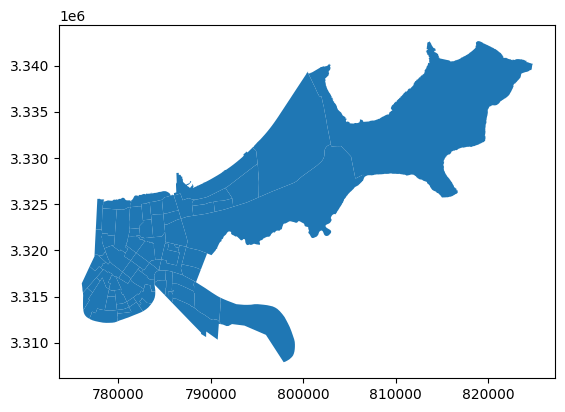

In [5]:
neighborFile = "./data/Neighborhood_Statistical_Area_20260520.geojson"
neighDf = gpd.read_file(neighborFile).set_crs('WGS84').to_crs(utmCRS)
neighDf.plot()

<Axes: >

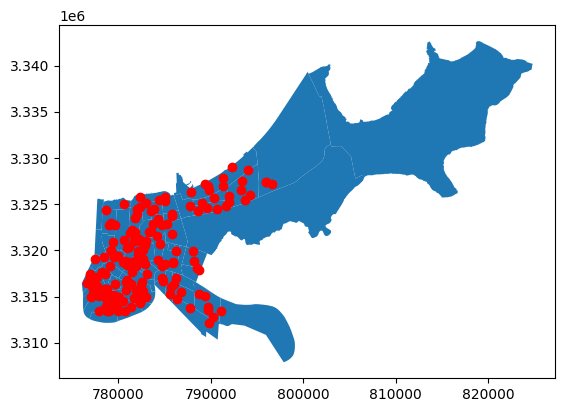

In [6]:
schoolsFile = "./data/Schools_20260520.geojson"
schoolDf = gpd.read_file(schoolsFile).set_crs('WGS84').to_crs(utmCRS)
fig, ax = plt.subplots(1)
neighDf.plot(ax=ax,markersize=10)
schoolDf.plot(ax=ax, color='red')

In [7]:
neighShp = neighDf.to_crs(wgsCRS).union_all()
cent = (neighShp.centroid.coords[0][1], neighShp.centroid.coords[0][0])

<Axes: >

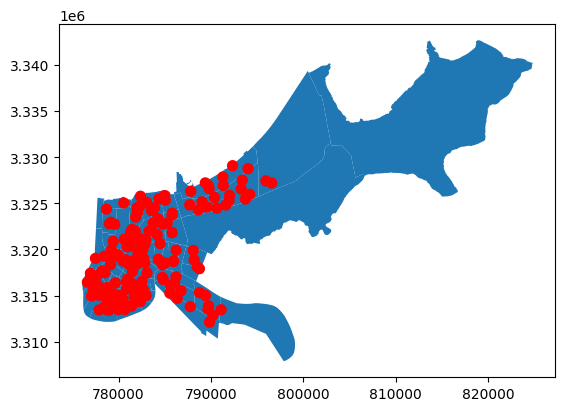

In [8]:
drugFreeZone = gpd.GeoSeries(schoolDf.buffer(radius).union_all()).set_crs(utmCRS)
fig, ax= plt.subplots(1)
neighDf.plot(ax=ax)
drugFreeZone.plot(ax=ax,color='red')

In [9]:
drugFreeZoneWGS = drugFreeZone.to_crs(wgsCRS)

In [10]:
fm = folium.Map(location=cent, zoom_start=12)

coords = [(pt[1],pt[0]) for pt in neighShp.exterior.coords]
folium.Polygon(coords).add_to(fm)

for poly in drugFreeZoneWGS.iloc[0].geoms:
    coords = [(pt[1],pt[0]) for pt in poly.exterior.coords]
    mapObj = folium.Polygon(coords,
                            color='red',
                           fill_color='red',
                           fill_opacity=0.2,
                           fill=True)
    mapObj.add_to(fm)

fm.save("output/HB568_DrugFreeZone.html")
print("If you seeing this on github, the output for this cell will be blank, but you can view it @ #https://s3.amazonaws.com/filestogeaux.garyscorner.net/pub/NewOrleansHB568/HB568_DrugFreeZone.html")
fm

If you seeing this on github, the output for this cell will be blank, but you can view it @ #https://s3.amazonaws.com/filestogeaux.garyscorner.net/pub/NewOrleansHB568/HB568_DrugFreeZone.html


In [11]:
#https://s3.amazonaws.com/filestogeaux.garyscorner.net/pub/NewOrleansHB568/HB568_DrugFreeZone.html
#this line wont work for anyone other than me
!aws s3 cp ./output/HB568_DrugFreeZone.html s3://filestogeaux.garyscorner.net/pub/NewOrleansHB568/HB568_DrugFreeZone.html --acl public-read

upload: output/HB568_DrugFreeZone.html to s3://filestogeaux.garyscorner.net/pub/NewOrleansHB568/HB568_DrugFreeZone.html


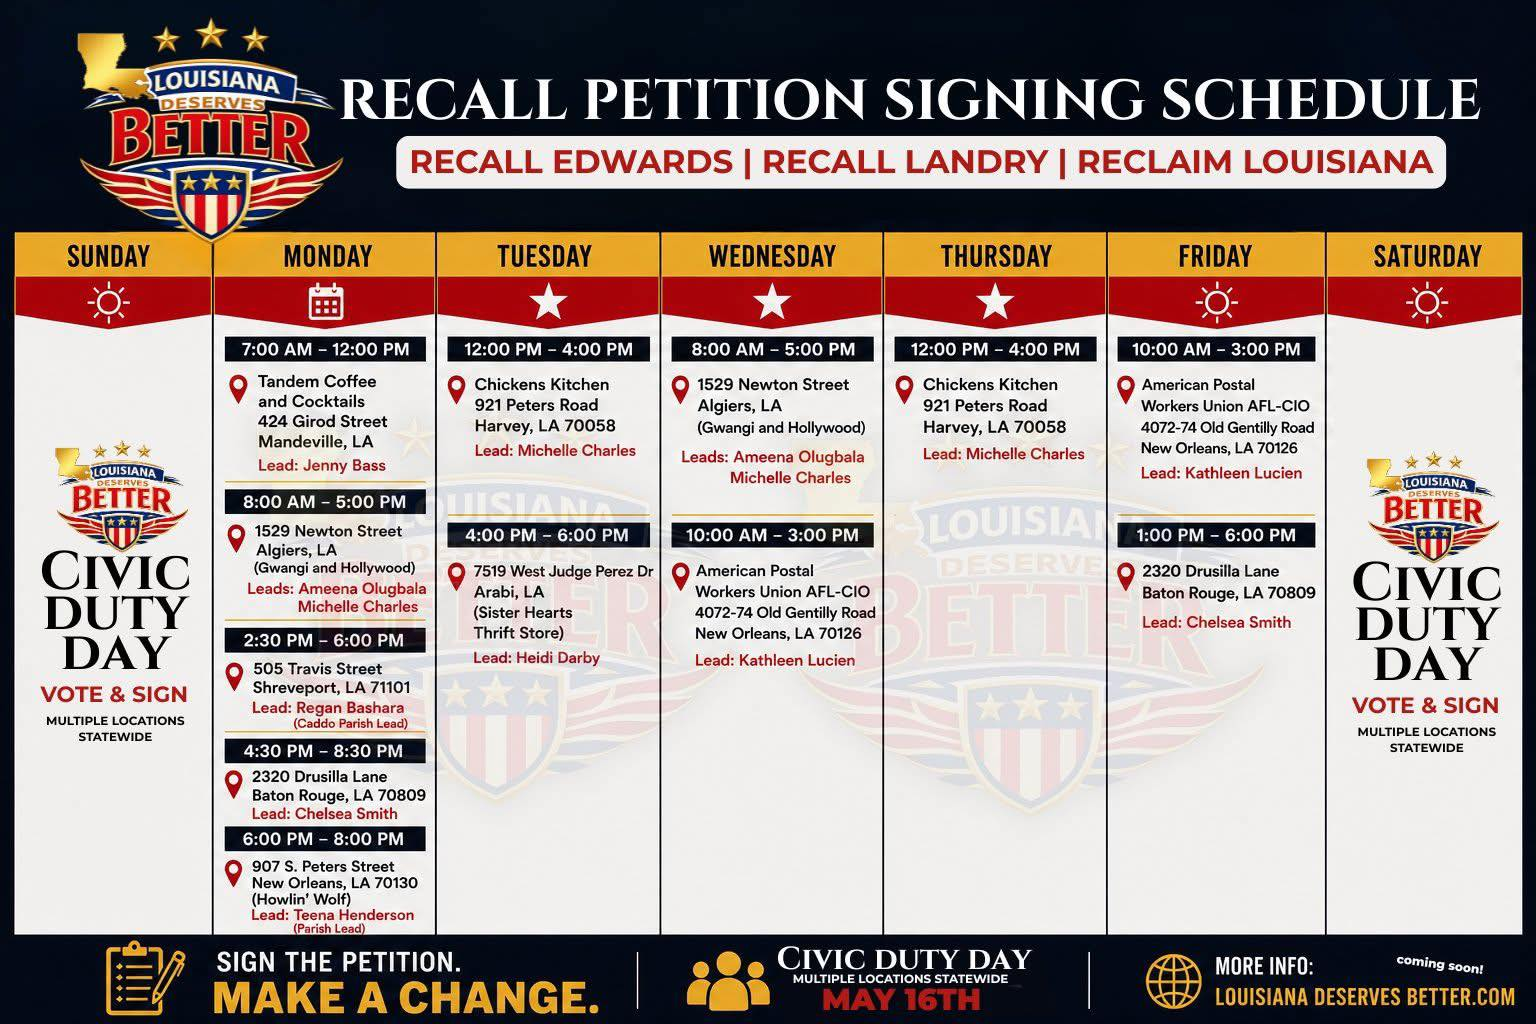